In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# Set style for all plots
sns.set_style("darkgrid") # Options: darkgrid, whitegrid, dark, white, ticks
sns.set_palette("husl")
# Color palette
# Load built-in datasets for examples
tips = sns.load_dataset('tips')
iris = sns.load_dataset('iris')
titanic = sns.load_dataset('titanic')
print("Tips dataset:")
print(tips.head())
print("\nIris dataset:")
print(iris.head())

Tips dataset:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Iris dataset:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


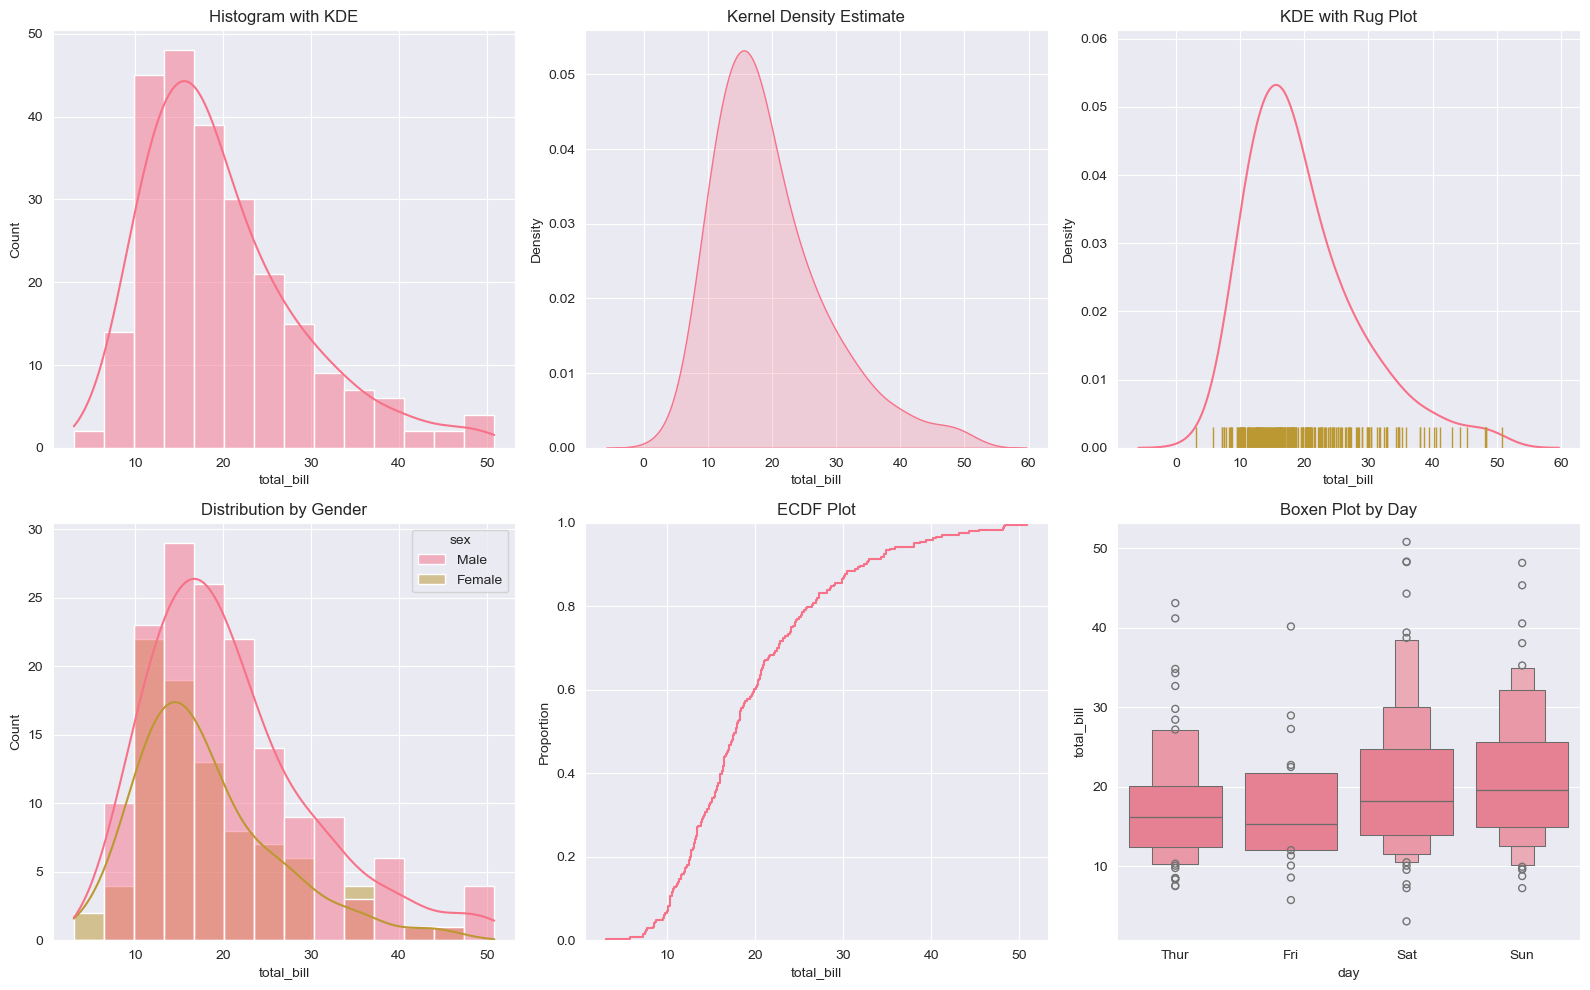

In [14]:
# Create a figure with multiple distribution plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# 1. Histogram with KDE
sns.histplot(data=tips, x='total_bill', kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Histogram with KDE')
# 2. KDE plot only
sns.kdeplot(data=tips, x='total_bill', fill=True, ax=axes[0, 1])
axes[0, 1].set_title('Kernel Density Estimate')
# 3. Rug plot (shows individual points)
sns.kdeplot(data=tips, x='total_bill', ax=axes[0, 2])
sns.rugplot(data=tips, x='total_bill', height=0.05, ax=axes[0, 2])
axes[0, 2].set_title('KDE with Rug Plot')
# 4. Distribution by category
sns.histplot(data=tips, x='total_bill', hue='sex', kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Distribution by Gender')
# 5. ECDF (Empirical Cumulative Distribution Function)
sns.ecdfplot(data=tips, x='total_bill', ax=axes[1, 1])
axes[1, 1].set_title('ECDF Plot')
# 6. Boxen plot (large dataset version of boxplot)
sns.boxenplot(data=tips, x='day', y='total_bill', ax=axes[1, 2])
axes[1, 2].set_title('Boxen Plot by Day')
plt.tight_layout()
plt.show()

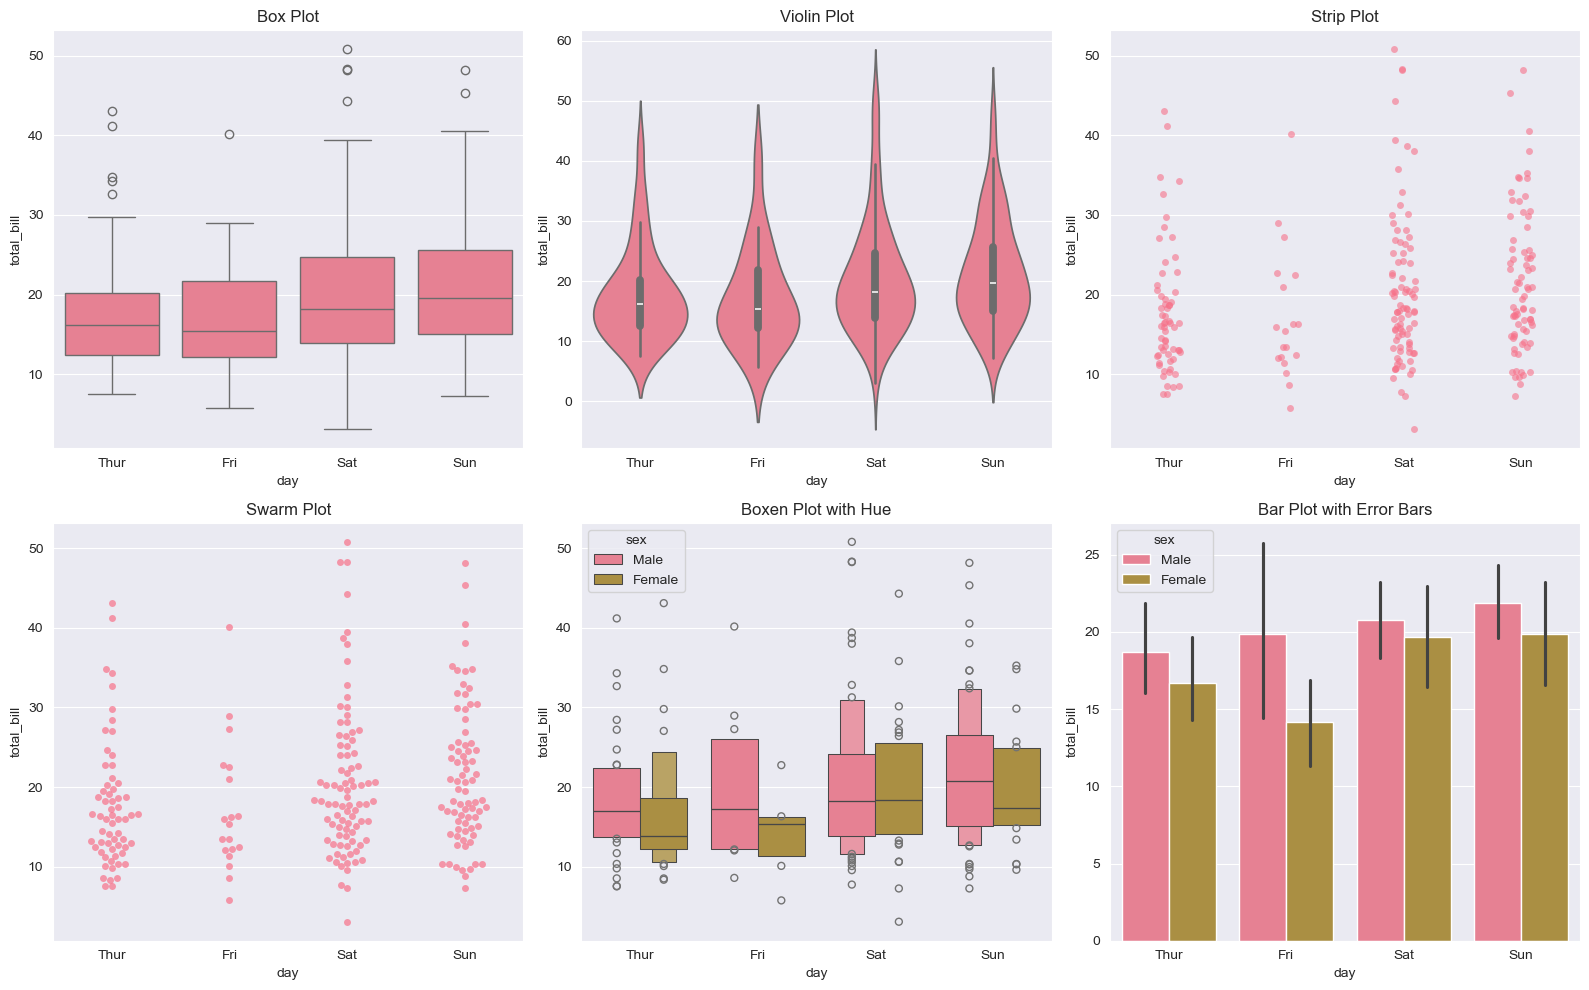

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# 1. Box plot
sns.boxplot(data=tips, x='day', y='total_bill', ax=axes[0, 0])
axes[0, 0].set_title('Box Plot')
# 2. Violin plot (combination of boxplot and KDE)
sns.violinplot(data=tips, x='day', y='total_bill', ax=axes[0, 1])
axes[0, 1].set_title('Violin Plot')
# 3. Stripplot (all points)
sns.stripplot(data=tips, x='day', y='total_bill', jitter=True, alpha=0.6, ax=axes[0, 2])
axes[0, 2].set_title('Strip Plot')
# 4. Swarm plot (points with non-overlapping layout)
sns.swarmplot(data=tips, x='day', y='total_bill', alpha=0.7, ax=axes[1, 0])
axes[1, 0].set_title('Swarm Plot')
# 5. Boxen plot with hue
sns.boxenplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[1, 1])
axes[1, 1].set_title('Boxen Plot with Hue')
# 6. Bar plot with error bars
sns.barplot(data=tips, x='day', y='total_bill', hue='sex', ax=axes[1, 2])
axes[1, 2].set_title('Bar Plot with Error Bars')
plt.tight_layout()
plt.show()

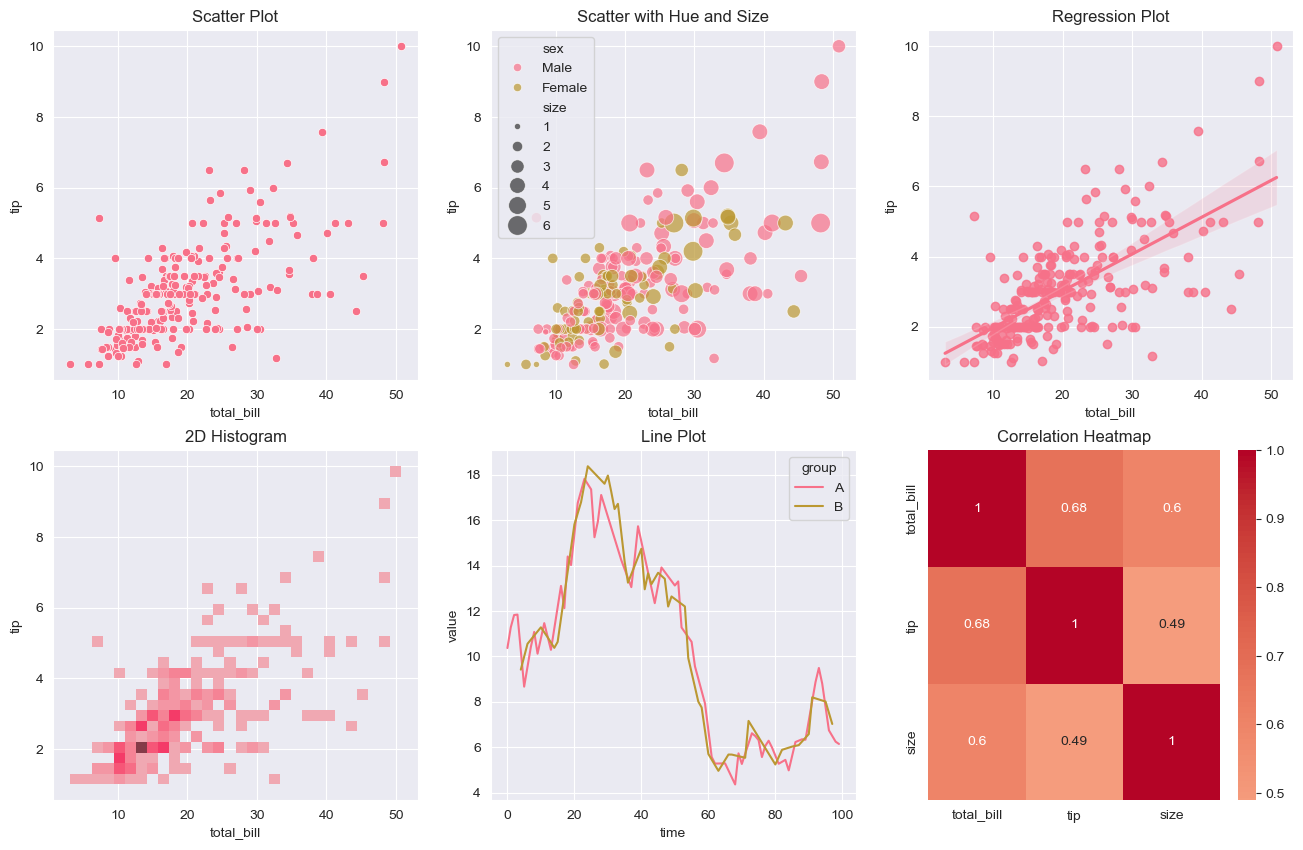

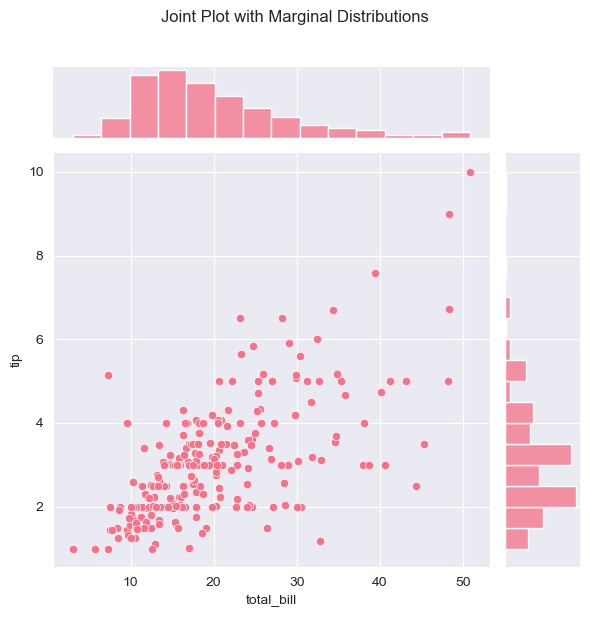

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# 1. Scatter plot
sns.scatterplot(data=tips, x='total_bill', y='tip', ax=axes[0, 0])
axes[0, 0].set_title('Scatter Plot')
# 2. Scatter plot with hue
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex', size='size',
sizes=(20, 200), alpha=0.7, ax=axes[0, 1])
axes[0, 1].set_title('Scatter with Hue and Size')
# 3. Regression plot (scatter + regression line)
sns.regplot(data=tips, x='total_bill', y='tip', ax=axes[0, 2])
axes[0, 2].set_title('Regression Plot')
# 4. Joint plot (scatter + distributions)- returns its own figure
# This one creates a new figure
g =sns.jointplot(data=tips, x='total_bill', y='tip', kind='scatter')
g.fig.suptitle('Joint Plot with Marginal Distributions', y=1.02)
# Can't place in subplot easily, so we'll move to next
# 5. Hexbin plot (for dense data)
sns.histplot(data=tips, x='total_bill', y='tip', bins=30, ax=axes[1, 0])
axes[1, 0].set_title('2D Histogram')
# 6. Line plot (for time series or ordered data)
# Create sample time series
time_data = pd.DataFrame({
'time': range(100),
'value': np.cumsum(np.random.randn(100)) + 10,
'group': np.random.choice(['A', 'B'], 100)
})
sns.lineplot(data=time_data, x='time', y='value', hue='group', ax=axes[1, 1])
axes[1, 1].set_title('Line Plot')
# 7. Heatmap (for correlation matrices)- placeholder
correlation = tips[['total_bill', 'tip', 'size']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, ax=axes[1, 2])
axes[1, 2].set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

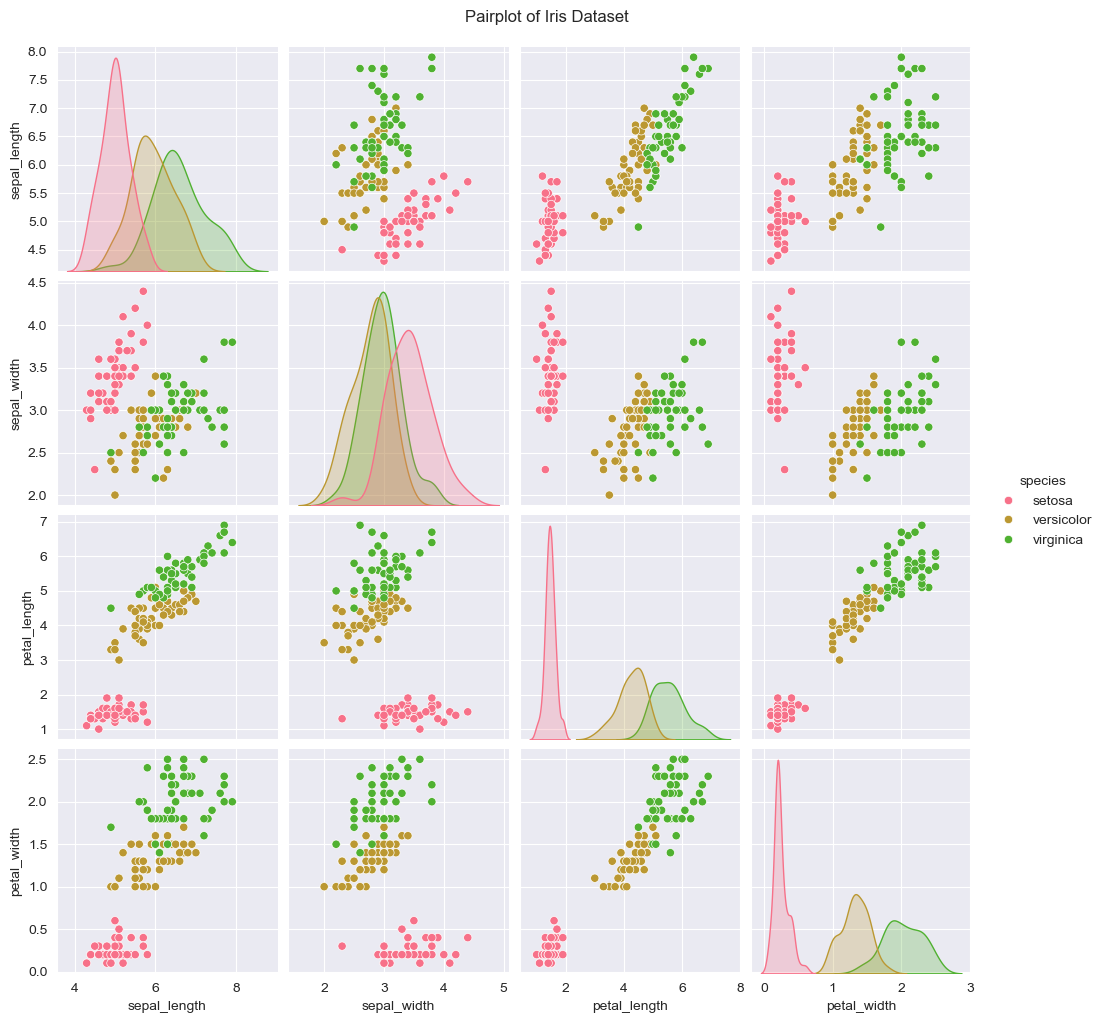

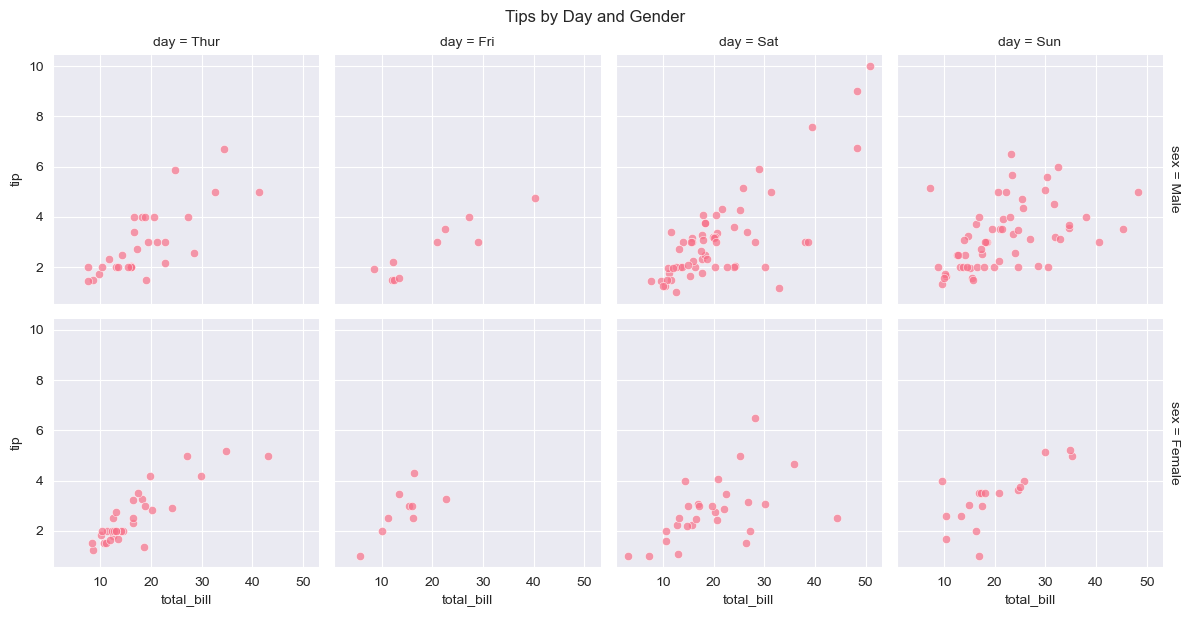

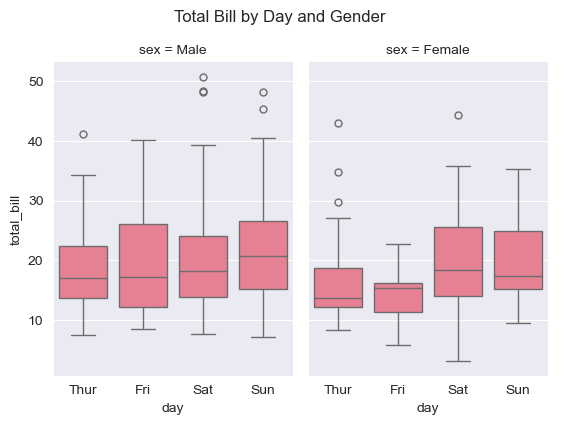

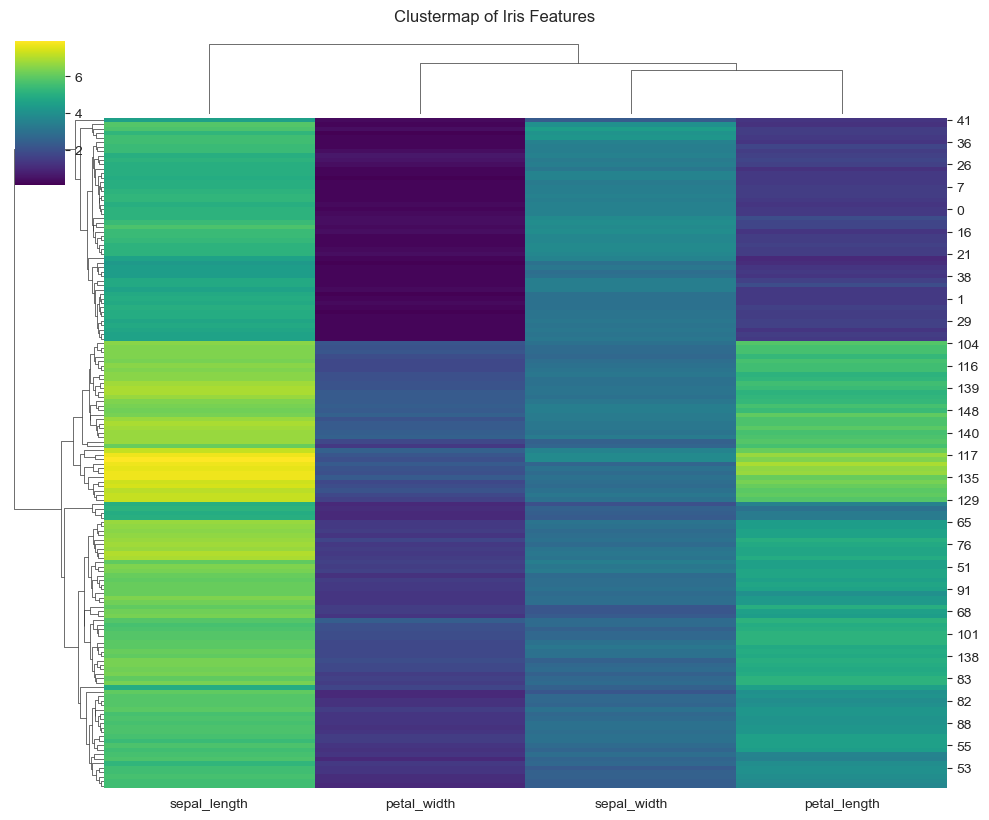

In [17]:
# 1. Pairplot (all pairwise relationships)
# This creates a large grid, so we'll just show one example
g =sns.pairplot(iris, hue='species', diag_kind='kde')
g.fig.suptitle('Pairplot of Iris Dataset', y=1.02)
plt.show()
# 2. FacetGrid (multiple plots by categories)
g =sns.FacetGrid(tips, col='day', row='sex', margin_titles=True)
g.map(sns.scatterplot, 'total_bill', 'tip', alpha=0.7)
g.fig.suptitle('Tips by Day and Gender', y=1.02)
plt.show()
# 3. Catplot (categorical plots with facets)
g =sns.catplot(data=tips, x='day', y='total_bill', col='sex',
kind='box', height=4, aspect=0.7)
g.fig.suptitle('Total Bill by Day and Gender', y=1.05)
plt.show()
# 4. Clustermap (heatmap with clustering)
# Prepare data for clustering
iris_numeric = iris.drop('species', axis=1)
g =sns.clustermap(iris_numeric, cmap='viridis',
figsize=(10, 8), dendrogram_ratio=0.1)
g.fig.suptitle('Clustermap of Iris Features', y=1.02)
plt.show()

C:\Users\muham\AppData\Local\Temp\ipykernel_21060\3674469963.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = tips.groupby(['day', 'sex'])['total_bill'].mean().unstack()


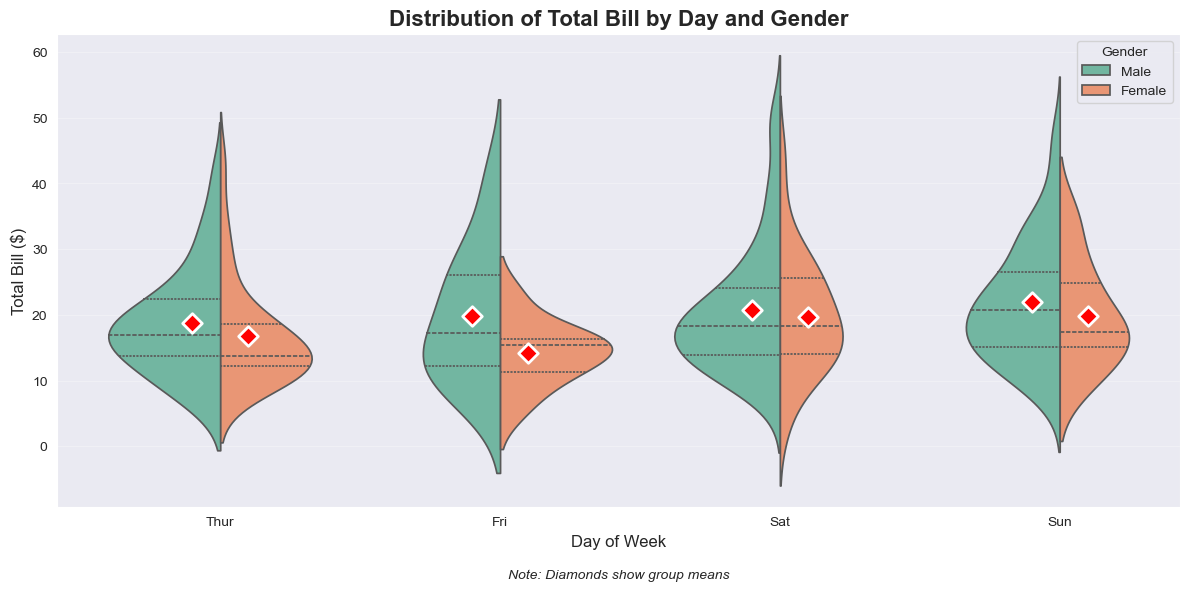

In [18]:
# Create a customized visualization
plt.figure(figsize=(12, 6))
# Main plot
ax = sns.violinplot(data=tips, x='day', y='total_bill', hue='sex',
split=True, inner='quartile', palette='Set2')
# Customization
ax.set_title('Distribution of Total Bill by Day and Gender', fontsize=16, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Total Bill ($)', fontsize=12)
# Add grid for readability
ax.grid(True, alpha=0.3, axis='y')
# Add mean markers
means = tips.groupby(['day', 'sex'])['total_bill'].mean().unstack()
for i, day in enumerate(['Thur', 'Fri', 'Sat', 'Sun']):
    for j, sex in enumerate(['Male', 'Female']):
        if sex in means.columns:
            ax.scatter(i + (j-0.5)*0.2, means.loc[day, sex],
            color='red', s=100, marker='D',
            edgecolor='white', linewidth=2, zorder=10)
# Legend customization
ax.legend(title='Gender', loc='upper right')
# Add text annotation
ax.text(0.5,-0.15, 'Note: Diamonds show group means',
transform=ax.transAxes, ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.show()